In [25]:
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

import sim_ranking as sr
import ml_tools as mlt

warnings.simplefilter(action='ignore', category=FutureWarning)

In [26]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/gnn/simple/1125_1953_cv_test_4_8")
wdata = Path("/Users/claudy/dev/work/data")

In [27]:
run_config = sr.ml.gnn_gm.RunConfig.from_yaml(results_dir / "run_config.yaml")

In [28]:
# Load observed data to get metadata
nzgmdb_ffp = wdata / run_config.rel_obs_data_ffp
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)

In [29]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(obs_data.sites, obs_data.site_df)

In [30]:
# Load attention coefficients
val_attn_coefs = pd.read_parquet(results_dir / "val_attn_coeffs.parquet")

In [31]:
# Add site-to-site distance
row_ind = dist_matrix.index.get_indexer_for(val_attn_coefs.site_int)
col_ind = dist_matrix.columns.get_indexer_for(val_attn_coefs.obs_site)
val_attn_coefs["dist"] = dist_matrix.values[row_ind, col_ind]

In [37]:
val_attn_coefs.head()

,conv_0,conv_1,event,obs_site,site_int,cv_iter,dist
2019p376808_NAAS_NCDS,0.539282,0.682051,2019p376808,NCDS,NAAS,cv_0,3.512469
2019p376808_NAAS_NGHS,0.523796,0.668677,2019p376808,NGHS,NAAS,cv_0,4.151276
2019p376808_NAAS_NSPS,0.517124,0.662803,2019p376808,NSPS,NAAS,cv_0,4.426023
2019p376808_NAAS_HNPS,0.189480,0.317048,2019p376808,HNPS,NAAS,cv_0,22.528622
2019p376808_NCHS_NCDS,0.577370,0.713492,2019p376808,NCDS,NCHS,cv_0,1.927045


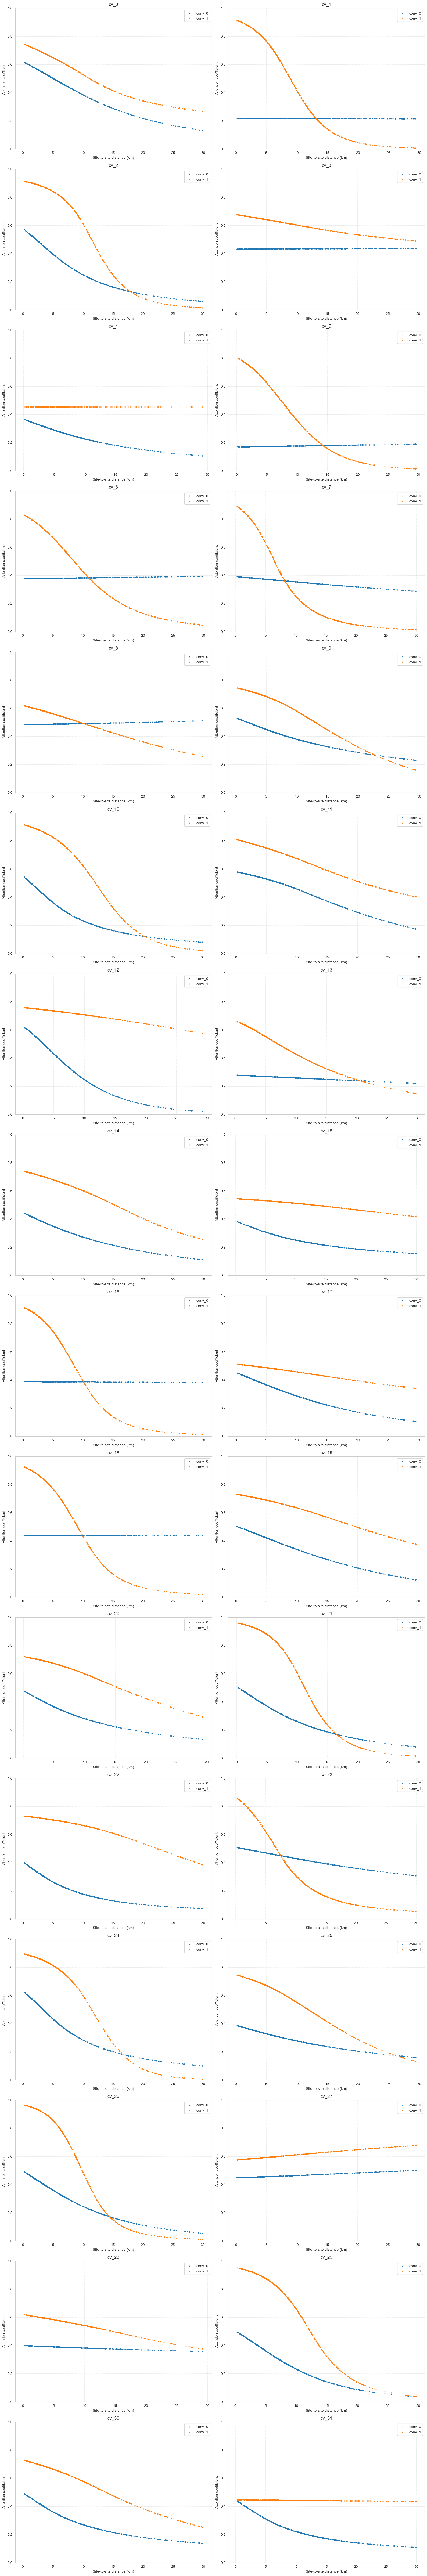

In [44]:
n_cv_iters = len(val_attn_coefs.cv_iter.unique())
conv_cols = [cur_col for cur_col in val_attn_coefs.columns if cur_col.startswith("conv_")]


fig, axs = mlt.plotting.get_fig_axes(n_cv_iters, 2, -1, (8, 6))

for ix, (cur_cv_iter, cur_ax) in enumerate(zip(val_attn_coefs.cv_iter.unique(), axs)):
	cur_data = val_attn_coefs.loc[val_attn_coefs.cv_iter == cur_cv_iter]

	for cur_conv in conv_cols:
	    cur_ax.scatter(cur_data.dist, cur_data[cur_conv], label=cur_conv, s=2.5)

	# if ix == 0:
	cur_ax.legend()

	cur_ax.set_xlabel("Site-to-site distance (km)")
	cur_ax.set_ylabel("Attention coefficient")
	cur_ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")
	cur_ax.set_title(f"{cur_cv_iter}")
	cur_ax.set_ylim(0, 1)

fig.tight_layout()

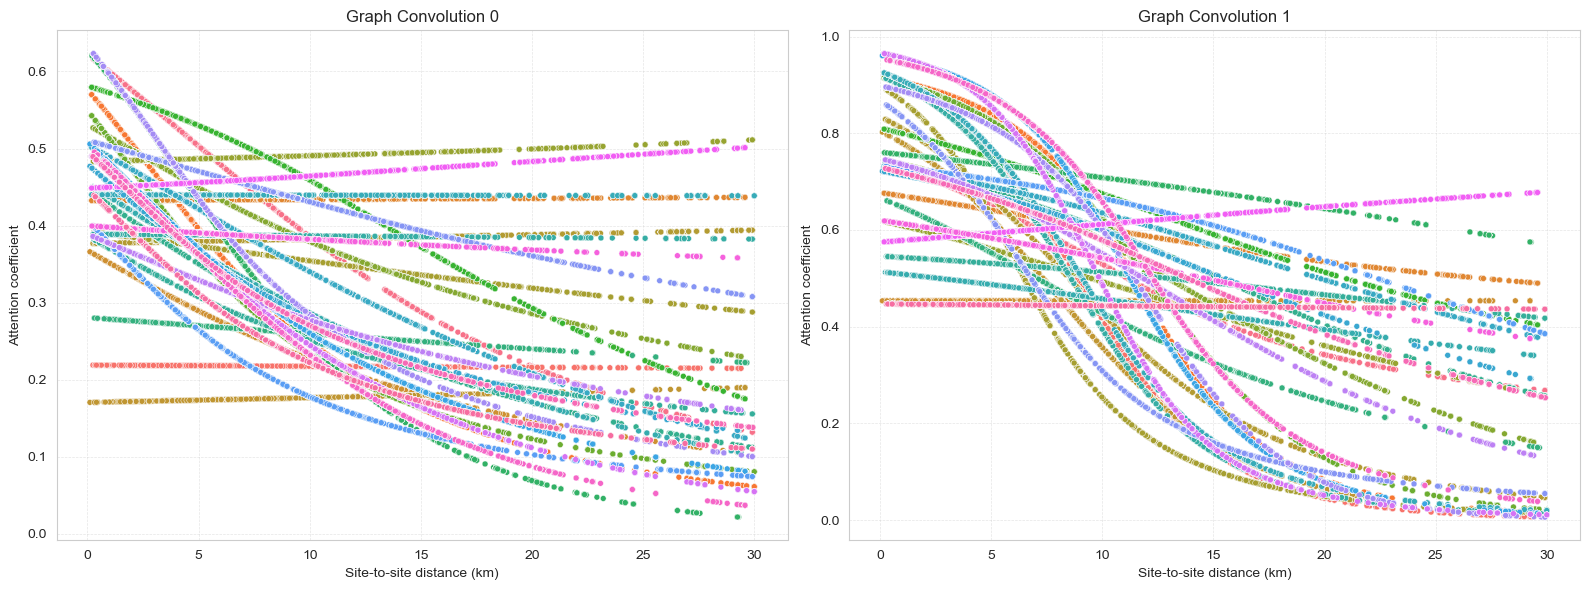

In [32]:
fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, (8, 6))

sns.scatterplot(data=val_attn_coefs, x="dist", y="conv_0", ax=ax1, hue="cv_iter", legend=False, size=1.0)
ax1.set_xlabel("Site-to-site distance (km)")
ax1.set_ylabel("Attention coefficient")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Graph Convolution 0")

sns.scatterplot(data=val_attn_coefs, x="dist", y="conv_1", ax=ax2, hue="cv_iter", legend=False, size=1.0)
ax2.set_xlabel("Site-to-site distance (km)")
ax2.set_ylabel("Attention coefficient")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Graph Convolution 1")

fig.tight_layout()

In [33]:
val_attn_coefs.cv_iter.unique()

array(['cv_0', 'cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7',
       'cv_8', 'cv_9', 'cv_10', 'cv_11', 'cv_12', 'cv_13', 'cv_14',
       'cv_15', 'cv_16', 'cv_17', 'cv_18', 'cv_19', 'cv_20', 'cv_21',
       'cv_22', 'cv_23', 'cv_24', 'cv_25', 'cv_26', 'cv_27', 'cv_28',
       'cv_29', 'cv_30', 'cv_31'], dtype=object)

In [34]:
val_attn_coefs.loc[val_attn_coefs.cv_iter == "cv_0"].sort_index()

,conv_0,conv_1,event,obs_site,site_int,cv_iter,dist
1974827_PHFS_ARKS,0.539263,0.682035,1974827,ARKS,PHFS,cv_0,3.513235
1974827_PHFS_INSS,0.562692,0.701605,1974827,INSS,PHFS,cv_0,2.541496
1974827_PHFS_LHES,0.513844,0.659889,1974827,LHES,PHFS,cv_0,4.561011
1974827_PHFS_SNZO,0.244143,0.368365,1974827,SNZO,PHFS,cv_0,17.883371
1974827_PHFS_UHCS,0.241496,0.365739,1974827,UHCS,PHFS,cv_0,18.076801
...,...,...,...,...,...,...,...
3713809_HPSC_NBLC,0.565442,0.703853,3713809,NBLC,HPSC,cv_0,2.426769
3713809_HPSC_STKS,0.332293,0.464649,3713809,STKS,HPSC,cv_0,12.565331
3713809_HPSC_SWNC,0.192089,0.319368,3713809,SWNC,HPSC,cv_0,22.269110
3749037_SPFS_KOWC,0.472225,0.621404,3749037,KOWC,SPFS,cv_0,6.275205


In [35]:
val_attn_coefs.loc[val_attn_coefs.cv_iter == "cv_1"].sort_index()

,conv_0,conv_1,event,obs_site,site_int,cv_iter,dist
2012p001896_GODS_CACS,0.215729,0.029434,2012p001896,CACS,GODS,cv_1,22.026878
2012p001896_GODS_CMHS,0.217189,0.291112,2012p001896,CMHS,GODS,cv_1,11.787242
2012p001896_GODS_CRLZ,0.217189,0.291268,2012p001896,CRLZ,GODS,cv_1,11.784707
2012p001896_GODS_KPOC,0.215446,0.019485,2012p001896,KPOC,GODS,cv_1,24.040026
2012p001896_GODS_MQZ,0.216443,0.089298,2012p001896,MQZ,GODS,cv_1,16.987810
...,...,...,...,...,...,...,...
3721796_RHSC_SHLC,0.217637,0.516823,3721796,SHLC,RHSC,cv_1,8.696103
3792018_SHFC_DFHS,0.217074,0.244791,3792018,DFHS,SHFC,cv_1,12.586473
3792018_SHFC_GDLC,0.215691,0.027809,3792018,GDLC,SHFC,cv_1,22.298988
3792018_SHFC_KOWC,0.216604,0.115851,3792018,KOWC,SHFC,cv_1,15.860623


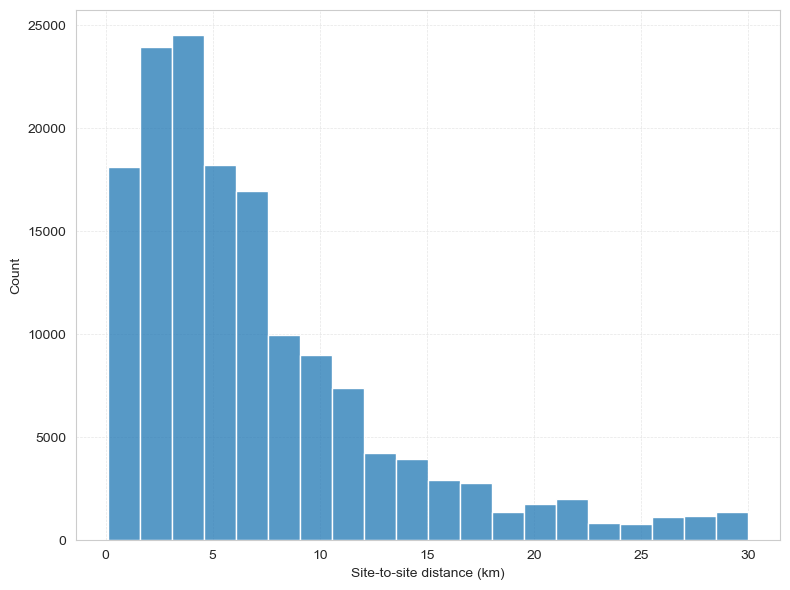

In [36]:
## Site-to-site distance distribution
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(val_attn_coefs["dist"], bins=20, ax=ax)

ax.set_xlabel("Site-to-site distance (km)")
ax.set_ylabel("Count")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()
